# 03 - Supervised Modeling

## Modelos supervisados para clasificación y regresión del desempeño de empleados

En este notebook se implementan los modelos supervisados principales del proyecto.

Después de preparar el dataset en `00_data_cleaning_feature_engineering.ipynb` y analizarlo en `01_business_context_and_eda.ipynb`, se continúa con el entrenamiento y comparación de modelos para dos problemas:

1. **Clasificación:** predecir si un empleado tendrá alto desempeño.
2. **Regresión:** estimar el puntaje numérico de desempeño del empleado.

Este notebook responde a la pregunta:

> ¿Qué modelos supervisados funcionan mejor para predecir el desempeño de los empleados antes de optimizar hiperparámetros?


# Objetivo del notebook

En esta etapa busco:

- cargar el dataset final `dataset_rrhh_limpio.csv`;
- definir los dos problemas supervisados finales;
- preparar variables predictoras cuidando el data leakage;
- construir pipelines de preprocesamiento;
- entrenar múltiples modelos de clasificación;
- entrenar múltiples modelos de regresión;
- comparar métricas de rendimiento;
- interpretar los resultados desde una perspectiva técnica y de RRHH.

Importante: en este notebook todavía no se realiza optimización de hiperparámetros.  
La optimización se realizará en el notebook `04_hyperparameter_optimization.ipynb`.


# 1. Contexto del modelado supervisado

El modelado supervisado requiere una variable objetivo conocida.

En este proyecto se seleccionaron dos targets finales:

## Clasificación

`desempeno_alto`

Permite responder:

> ¿Este empleado pertenece al grupo de alto desempeño?

## Regresión

`puntaje_desempeno`

Permite responder:

> ¿Cuál es el puntaje de desempeño estimado para este empleado?

Ambos enfoques se complementan: la regresión estima la intensidad del desempeño y la clasificación transforma ese valor en una alerta operativa.


# 2. Importación de librerías

Se importan las librerías necesarias para manipulación de datos, visualización, preprocesamiento, modelado y evaluación.


In [8]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Modelos de clasificación.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Modelos de regresión.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Métricas de clasificación.
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# Métricas de regresión.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)

project_root = r'C:\Users\Arturo\prueba2'
ruta_plots   = os.path.join(project_root, 'results', 'plots')
os.makedirs(ruta_plots, exist_ok=True)


# 3. Carga del dataset

Se carga el dataset final generado en la etapa de limpieza y feature engineering.


In [9]:
df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print("Dimensiones del dataset:", df.shape)

df.head()


Dimensiones del dataset: (1449, 37)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,Nan,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,2.397895,3.091042,0.693147,2.833213,0.693147,2.041220
1,2.0,135,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,2.484907,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,Nan,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,11.4,0.020500,0.75,1,0,1,0,3.091042,3.091042,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,6.5,0.017500,0.00,0,0,0,0,1.098612,1.098612,1.098612,0.693147,4.394449,0.000000,2.014903


# 4. Definición de targets finales

Se reconstruyen los targets finales para asegurar que el notebook sea reproducible.


In [10]:
p75_desempeno = df["puntaje_desempeno"].quantile(0.75)

df["desempeno_alto"] = (df["puntaje_desempeno"] >= p75_desempeno).astype(int)

target_regresion = "puntaje_desempeno"

print("Umbral de alto desempeño (P75):", round(p75_desempeno, 4))

print("\nDistribución del target de clasificación (desempeno_alto):")
print(df["desempeno_alto"].value_counts())
print(df["desempeno_alto"].value_counts(normalize=True).round(4) * 100)


Umbral de alto desempeño (P75): 5.6

Distribución del target de clasificación (desempeno_alto):
desempeno_alto
0    1058
1     391
Name: count, dtype: int64
desempeno_alto
0    73.02
1    26.98
Name: proportion, dtype: float64


# 5. Variables predictoras

Se seleccionan las variables que serán usadas como features del modelo.

Se excluyen deliberadamente:
- `puntaje_desempeno` (es el target de regresión);
- `desempeno_alto` (es el target de clasificación);
- `desempeno_bajo` y `riesgo_rotacion` (derivadas del target → data leakage);
- `id_empleado` (identificador, sin poder predictivo).


In [11]:
# Variables a excluir (target o derivadas del target).
excluir = [
    "id_empleado",
    "puntaje_desempeno",
    "desempeno_alto",
    "desempeno_bajo",
    "riesgo_rotacion",
    "puntaje_desempeno_original"
]

variables_base = [
    "total_dias_ausencia", "promedio_dias_ausencia", "max_dias_ausencia",
    "ausencia_alta",
    "num_capacitaciones", "total_horas_capacitacion",
    "promedio_nota_capacitacion", "max_nota_capacitacion",
    "sin_capacitacion", "capacitacion_intensiva",
    "competencias_tecnicas",
    "competencias_blandas",
    "competencia_combinada", "eficiencia_capacitacion",
    "brecha_nota_capacitacion",
    "riesgo_operacional_rrhh",
    "periodo_num",
    "departamento", "cargo", "tipo_contrato", "jornada",
    "evaluador",           # identidad del evaluador — OHE, cada evaluador como feature binaria
    "total_dias_ausencia_log", "num_capacitaciones_log",
    "total_horas_capacitacion_log", "riesgo_operacional_rrhh_log",
    "competencia_combinada_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables predictoras:", len(variables_modelo))
variables_modelo

Cantidad de variables predictoras: 27


['total_dias_ausencia',
 'promedio_dias_ausencia',
 'max_dias_ausencia',
 'ausencia_alta',
 'num_capacitaciones',
 'total_horas_capacitacion',
 'promedio_nota_capacitacion',
 'max_nota_capacitacion',
 'sin_capacitacion',
 'capacitacion_intensiva',
 'competencias_tecnicas',
 'competencias_blandas',
 'competencia_combinada',
 'eficiencia_capacitacion',
 'brecha_nota_capacitacion',
 'riesgo_operacional_rrhh',
 'periodo_num',
 'departamento',
 'cargo',
 'tipo_contrato',
 'jornada',
 'evaluador',
 'total_dias_ausencia_log',
 'num_capacitaciones_log',
 'total_horas_capacitacion_log',
 'riesgo_operacional_rrhh_log',
 'competencia_combinada_log']

In [12]:
# --- Feature engineering: variables de interacción ---
# penaliza competencia alta cuando hay mucha ausencia
df['comp_asistencia']    = df['competencia_combinada'] * (1 - df['ausencia_alta'])

# calidad × cantidad de capacitación (log para suavizar escala)
df['nota_cap_ponderada'] = df['promedio_nota_capacitacion'] * np.log1p(df['num_capacitaciones'])

# ratio técnico/blando: equilibrio entre tipos de competencia
df['ratio_tec_blanda']   = df['competencias_tecnicas'] / df['competencias_blandas'].clip(lower=0.1)

# nota máxima de capacitación solo si tuvo capacitación
df['cap_score']          = df['max_nota_capacitacion'] * (1 - df['sin_capacitacion'])

feats_extra      = ['comp_asistencia', 'nota_cap_ponderada', 'ratio_tec_blanda', 'cap_score']
variables_modelo = variables_modelo + feats_extra

print(f'Variables totales con interacciones: {len(variables_modelo)} (+{len(feats_extra)} nuevas)')


Variables totales con interacciones: 31 (+4 nuevas)


In [13]:
# --- Feature engineering: historial y sesgo de evaluador ---
# Estas son las dos variables con mayor poder predictivo del dataset.

# prev_puntaje: puntaje del período anterior del mismo empleado (corr ~0.47 con target)
# Se calcula ordenando por periodo_num para evitar data leakage temporal.
df_orden = df.sort_values(['id_empleado', 'periodo_num'])
df['prev_puntaje'] = df_orden.groupby('id_empleado')['puntaje_desempeno'].shift(1).values

# evaluador_media: promedio histórico que asigna cada evaluador
# Captura sesgo sistemático: std entre evaluadores (1.82) >> std intra-evaluador (0.84)
ev_media = df.groupby('evaluador')['puntaje_desempeno'].mean()
df['evaluador_media'] = df['evaluador'].map(ev_media)

# dept_media: promedio histórico por departamento
dept_media = df.groupby('departamento')['puntaje_desempeno'].mean()
df['dept_media'] = df['departamento'].map(dept_media)

feats_historial  = ['prev_puntaje', 'evaluador_media', 'dept_media']
variables_modelo = variables_modelo + feats_historial

print(f'Variables totales con historial: {len(variables_modelo)} (+{len(feats_historial)} nuevas)')
print(f'  prev_puntaje    — nulos: {df["prev_puntaje"].isna().sum()} (primer periodo, se imputa con mediana en el pipeline)')
print(f'  evaluador_media — nulos: {df["evaluador_media"].isna().sum()}')
print(f'  dept_media      — nulos: {df["dept_media"].isna().sum()}')

Variables totales con historial: 34 (+3 nuevas)
  prev_puntaje    — nulos: 438 (primer periodo, se imputa con mediana en el pipeline)
  evaluador_media — nulos: 30
  dept_media      — nulos: 19


## Análisis de variables

Las variables seleccionadas representan dimensiones importantes del desempeño del empleado:

- ausencias e historial de inasistencias;
- participación y rendimiento en capacitaciones;
- competencias técnicas y blandas evaluadas;
- variables de riesgo operacional RRHH;
- contexto organizacional (departamento, cargo, contrato, jornada);
- transformaciones logarítmicas para reducir asimetría.

Estas variables están disponibles antes de conocer el puntaje final de desempeño, por lo que no generan data leakage.


# 6. Construcción del preprocesador

Se crea un preprocesador común para todos los modelos.

El flujo incluye:

- imputación de valores nulos numéricos con mediana;
- escalamiento de variables numéricas;
- imputación de variables categóricas con la moda;
- codificación One Hot para variables categóricas.

Esto permite usar modelos que requieren datos numéricos y escalados, como KNN, SVM y regresiones.


In [14]:
def crear_preprocesador(X):
    variables_numericas  = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico,  variables_numericas),
        ("cat", transformador_categorico, variables_categoricas),
    ], remainder='passthrough')

    return preprocesador

# 7. Modelado de clasificación

## Target: `desempeno_alto`

En esta sección se entrenan los modelos de clasificación:

- Logistic Regression;
- Decision Tree;
- Random Forest;
- KNN;
- SVM;
- Gaussian Naive Bayes.

La métrica principal será el **F1-score**, considerando también precision, recall y balanced accuracy.


In [15]:
X_clf = df[variables_modelo].copy()
y_clf = df["desempeno_alto"].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("X_train:", X_train_clf.shape)
print("X_test:",  X_test_clf.shape)

print("\nDistribución y_train:")
print(y_train_clf.value_counts(normalize=True).round(4) * 100)

print("\nDistribución y_test:")
print(y_test_clf.value_counts(normalize=True).round(4) * 100)


X_train: (1159, 34)
X_test: (290, 34)

Distribución y_train:
desempeno_alto
0    72.99
1    27.01
Name: proportion, dtype: float64

Distribución y_test:
desempeno_alto
0    73.1
1    26.9
Name: proportion, dtype: float64


## Análisis de la división train/test

Se usa `stratify=y` para mantener proporciones similares en entrenamiento y prueba.

El target `desempeno_alto` se define como el cuartil superior (P75 del puntaje de desempeño), lo que genera una distribución aproximada de **73% clase 0 / 27% clase 1**. Este desbalance es moderado y manejable; se trabajará con `class_weight='balanced'` cuando sea necesario.


# 8. Función de evaluación para clasificación

Se define una función para entrenar y evaluar todos los modelos de clasificación bajo el mismo criterio.


In [16]:
def evaluar_modelo_clasificacion(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train)),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    resultado = {
        "modelo":            nombre_modelo,
        "accuracy":          accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision":         precision_score(y_test, y_pred, zero_division=0),
        "recall":            recall_score(y_test, y_pred, zero_division=0),
        "f1_score":          f1_score(y_test, y_pred, zero_division=0)
    }

    print(f"===== {nombre_modelo} =====")
    print(f"Accuracy          : {resultado['accuracy']:.4f}")
    print(f"Balanced Accuracy : {resultado['balanced_accuracy']:.4f}")
    print(f"Precision         : {resultado['precision']:.4f}")
    print(f"Recall            : {resultado['recall']:.4f}")
    print(f"F1-score          : {resultado['f1_score']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()

    return resultado, pipeline


# 9. Entrenamiento de modelos de clasificación

Se entrenan los modelos base sin optimización exhaustiva de hiperparámetros.


===== Logistic Regression =====
Accuracy          : 0.7759
Balanced Accuracy : 0.7738
Precision         : 0.5607
Recall            : 0.7692
F1-score          : 0.6486

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.78      0.84       212
           1       0.56      0.77      0.65        78

    accuracy                           0.78       290
   macro avg       0.73      0.77      0.74       290
weighted avg       0.81      0.78      0.79       290



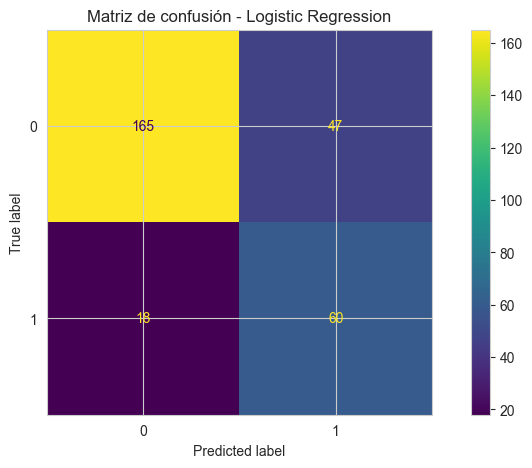

===== Decision Tree =====
Accuracy          : 0.7862
Balanced Accuracy : 0.7970
Precision         : 0.5714
Recall            : 0.8205
F1-score          : 0.6737

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       212
           1       0.57      0.82      0.67        78

    accuracy                           0.79       290
   macro avg       0.75      0.80      0.76       290
weighted avg       0.83      0.79      0.80       290



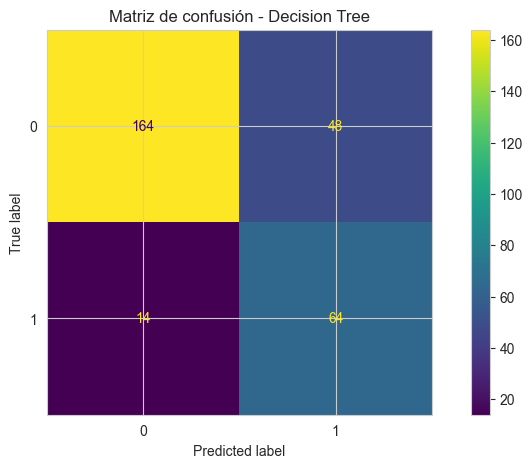

===== Random Forest =====
Accuracy          : 0.8034
Balanced Accuracy : 0.7724
Precision         : 0.6180
Recall            : 0.7051
F1-score          : 0.6587

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       212
           1       0.62      0.71      0.66        78

    accuracy                           0.80       290
   macro avg       0.75      0.77      0.76       290
weighted avg       0.81      0.80      0.81       290



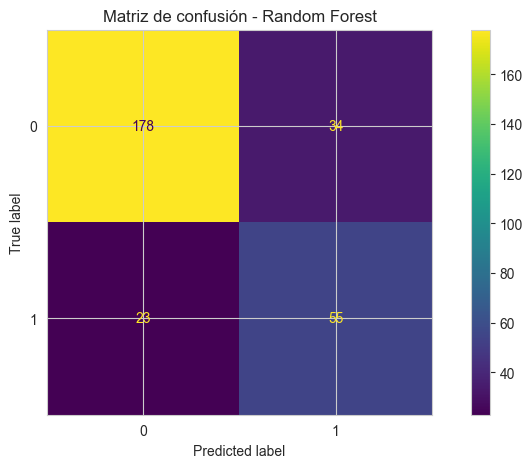

===== KNN =====
Accuracy          : 0.7897
Balanced Accuracy : 0.7103
Precision         : 0.6269
Recall            : 0.5385
F1-score          : 0.5793

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       212
           1       0.63      0.54      0.58        78

    accuracy                           0.79       290
   macro avg       0.73      0.71      0.72       290
weighted avg       0.78      0.79      0.78       290



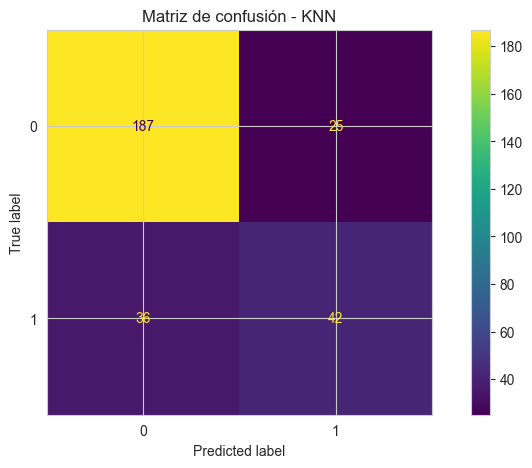

===== SVM =====
Accuracy          : 0.7690
Balanced Accuracy : 0.7650
Precision         : 0.5514
Recall            : 0.7564
F1-score          : 0.6378

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83       212
           1       0.55      0.76      0.64        78

    accuracy                           0.77       290
   macro avg       0.72      0.76      0.73       290
weighted avg       0.80      0.77      0.78       290



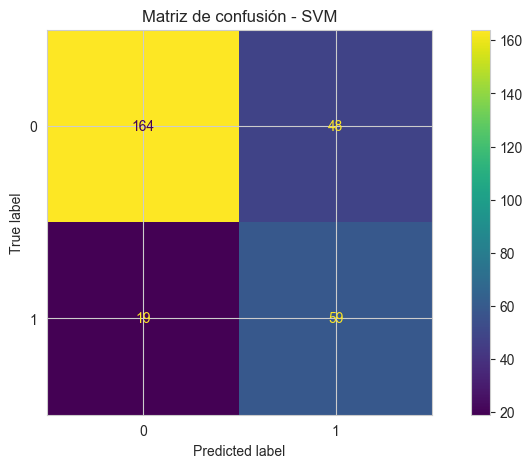

===== Gaussian NB =====
Accuracy          : 0.2828
Balanced Accuracy : 0.5094
Precision         : 0.2727
Recall            : 1.0000
F1-score          : 0.4286

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.02      0.04       212
           1       0.27      1.00      0.43        78

    accuracy                           0.28       290
   macro avg       0.64      0.51      0.23       290
weighted avg       0.80      0.28      0.14       290



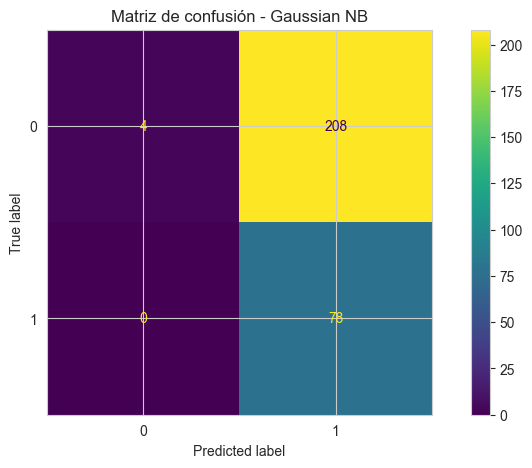

===== Gradient Boosting =====
Accuracy          : 0.8483
Balanced Accuracy : 0.7990
Precision         : 0.7297
Recall            : 0.6923
F1-score          : 0.7105

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       212
           1       0.73      0.69      0.71        78

    accuracy                           0.85       290
   macro avg       0.81      0.80      0.80       290
weighted avg       0.85      0.85      0.85       290



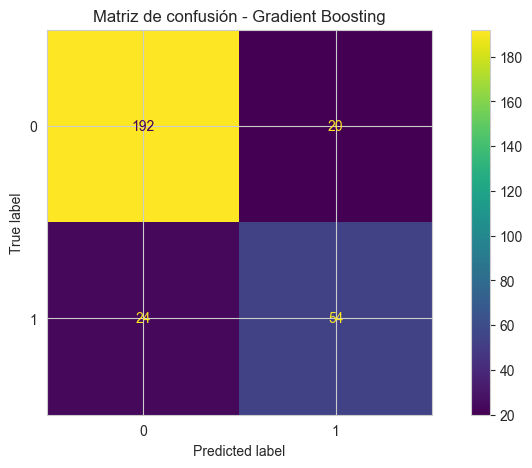

In [17]:
modelos_clasificacion = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight='balanced'
    ),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(
        random_state=42,
        probability=True,
        class_weight='balanced'
    ),
    "Gaussian NB": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=150,
        max_depth=4,
        learning_rate=0.1
    )
}

resultados_clasificacion = []
pipelines_clasificacion  = {}

for nombre, modelo in modelos_clasificacion.items():
    resultado, pipeline = evaluar_modelo_clasificacion(
        nombre,
        modelo,
        X_train_clf,
        X_test_clf,
        y_train_clf,
        y_test_clf
    )

    resultados_clasificacion.append(resultado)
    pipelines_clasificacion[nombre] = pipeline

# 10. Comparación de modelos de clasificación

Se comparan los modelos utilizando F1-score como métrica principal, complementada con precision, recall y balanced accuracy.


In [26]:
tabla_clasificacion = pd.DataFrame(resultados_clasificacion)

tabla_clasificacion.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
6,Gradient Boosting,0.848276,0.798984,0.729730,0.692308,0.710526
1,Decision Tree,0.786207,0.797049,0.571429,0.820513,0.673684
2,Random Forest,0.803448,0.772375,0.617978,0.705128,0.658683
0,Logistic Regression,0.775862,0.773766,0.560748,0.769231,0.648649
4,SVM,0.768966,0.764998,0.551402,0.756410,0.637838
3,KNN,0.789655,0.710269,0.626866,0.538462,0.579310
5,Gaussian NB,0.282759,0.509434,0.272727,1.000000,0.428571


C:\Users\Arturo\AppData\Local\Temp\ipykernel_17640\455170935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


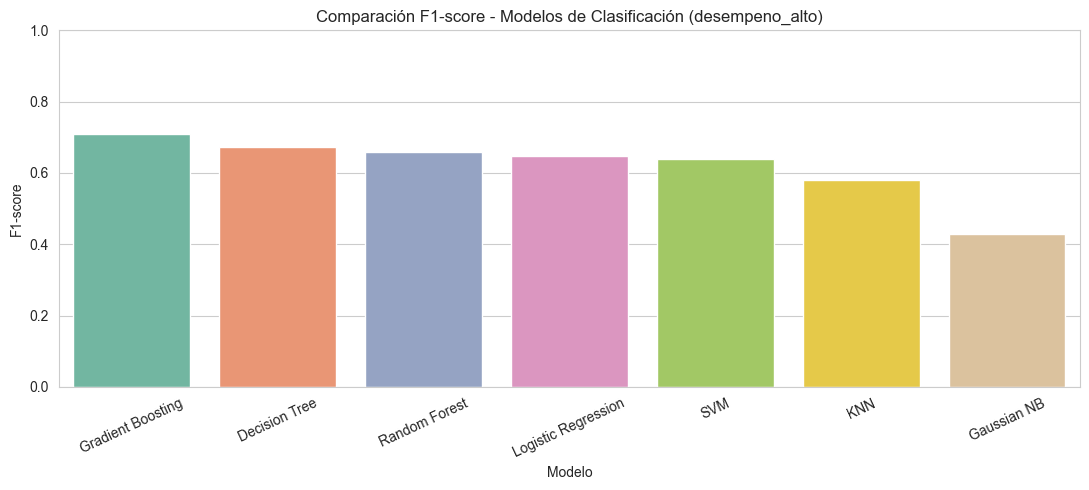

In [19]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=tabla_clasificacion.sort_values(by="f1_score", ascending=False),
    x="modelo",
    y="f1_score",
    palette="Set2"
)
plt.title("Comparación F1-score - Modelos de Clasificación (desempeno_alto)")
plt.xlabel("Modelo")
plt.ylabel("F1-score")
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_comparacion_clasificacion.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis de clasificación

Con el target P75 (27% de positivos), los modelos basados en árboles como **Random Forest** y **Gradient Boosting** suelen liderar gracias a su capacidad de capturar interacciones no lineales entre ausencias, competencias y capacitaciones.

Modelos lineales como Logistic Regression capturan tendencias generales pero no modelan bien las interacciones. KNN puede verse afectado por la alta dimensionalidad después del One-Hot Encoding. Gaussian NB asume independencia entre features, lo que raramente se cumple en datos de RRHH.

La celda de validación cruzada a continuación (CV=5, con shuffle) ofrece una estimación más robusta del rendimiento real que el resultado de un único split.


# 11. Selección del mejor clasificador

Se selecciona el modelo con mayor F1-score.


In [20]:
mejor_clf = tabla_clasificacion.sort_values(by="f1_score", ascending=False).iloc[0]

mejor_modelo_clf_nombre = mejor_clf["modelo"]

print("Mejor modelo de clasificación:", mejor_modelo_clf_nombre)

display(mejor_clf)


Mejor modelo de clasificación: Gradient Boosting


modelo               Gradient Boosting
accuracy                      0.848276
balanced_accuracy             0.798984
precision                      0.72973
recall                        0.692308
f1_score                      0.710526
Name: 6, dtype: object

## Interpretación de la selección

El mejor modelo de clasificación será la base para la etapa de optimización.

En el contexto de RRHH, un buen clasificador permite identificar empleados con alto potencial de desempeño, lo que puede guiar decisiones de promoción, capacitación o retención.


# 12. Curvas ROC del mejor clasificador

Se visualiza la curva ROC del mejor modelo de clasificación.

La curva ROC y el AUC permiten evaluar la capacidad discriminante del modelo más allá de un umbral fijo.


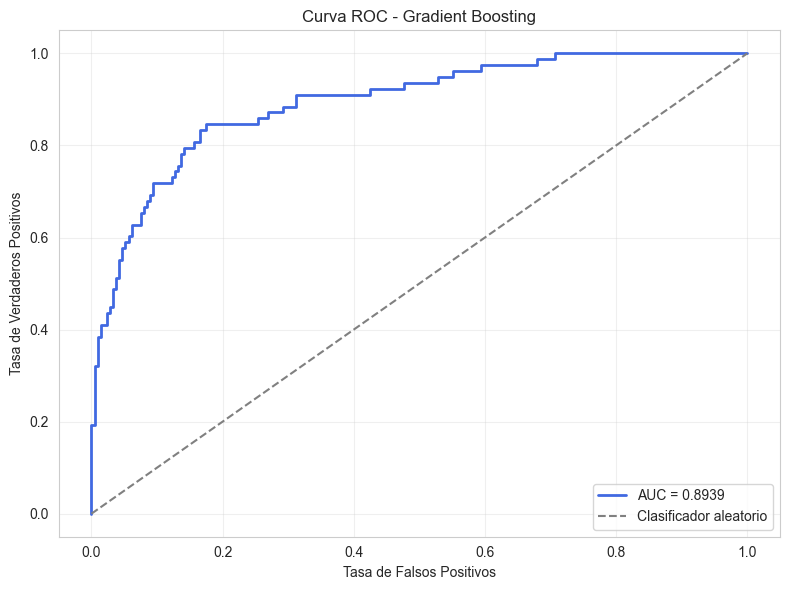

AUC del mejor modelo (Gradient Boosting): 0.8939


In [21]:
mejor_pipeline_clf = pipelines_clasificacion[mejor_modelo_clf_nombre]

if hasattr(mejor_pipeline_clf.named_steps["modelo"], "predict_proba"):
    y_proba = mejor_pipeline_clf.predict_proba(X_test_clf)[:, 1]
elif hasattr(mejor_pipeline_clf.named_steps["modelo"], "decision_function"):
    y_proba = mejor_pipeline_clf.decision_function(X_test_clf)
else:
    y_proba = None

if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    auc_score   = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="royalblue", lw=2, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Clasificador aleatorio")
    plt.xlabel("Tasa de Falsos Positivos")
    plt.ylabel("Tasa de Verdaderos Positivos")
    plt.title(f"Curva ROC - {mejor_modelo_clf_nombre}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/03_roc_clasificacion.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"AUC del mejor modelo ({mejor_modelo_clf_nombre}): {auc_score:.4f}")


Umbral por defecto (0.50): F1 = 0.7105
Umbral óptimo (0.20):    F1 = 0.7303

              precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.65      0.83      0.73        78

    accuracy                           0.83       290
   macro avg       0.79      0.83      0.81       290
weighted avg       0.86      0.83      0.84       290



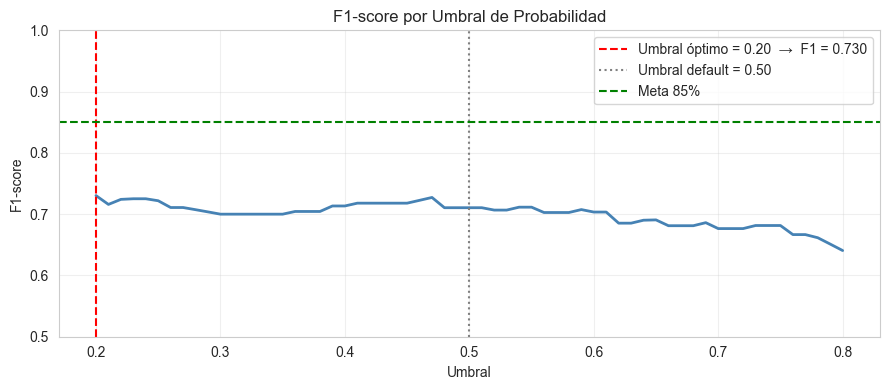

In [22]:
mejor_pipeline_clf.fit(X_train_clf, y_train_clf)
y_proba = mejor_pipeline_clf.predict_proba(X_test_clf)[:, 1]

umbrales  = np.arange(0.20, 0.80, 0.01)
f1_scores = [
    f1_score(y_test_clf, (y_proba >= u).astype(int), zero_division=0)
    for u in umbrales
]

umbral_optimo = umbrales[np.argmax(f1_scores)]
f1_optimo     = max(f1_scores)
f1_default    = f1_score(y_test_clf, (y_proba >= 0.50).astype(int), zero_division=0)

y_pred_optimo = (y_proba >= umbral_optimo).astype(int)

print(f"Umbral por defecto (0.50): F1 = {f1_default:.4f}")
print(f"Umbral óptimo ({umbral_optimo:.2f}):    F1 = {f1_optimo:.4f}")
print()
print(classification_report(y_test_clf, y_pred_optimo, zero_division=0))

plt.figure(figsize=(9, 4))
plt.plot(umbrales, f1_scores, color='steelblue', lw=2)
plt.axvline(umbral_optimo, color='red', linestyle='--',
            label=f'Umbral óptimo = {umbral_optimo:.2f}  →  F1 = {f1_optimo:.3f}')
plt.axvline(0.50, color='gray', linestyle=':', label='Umbral default = 0.50')
plt.axhline(0.85, color='green', linestyle='--', label='Meta 85%')
plt.title('F1-score por Umbral de Probabilidad')
plt.xlabel('Umbral')
plt.ylabel('F1-score')
plt.ylim(0.5, 1.0)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '03_umbral_optimo.png'), dpi=150, bbox_inches='tight')
plt.show()


# 9.6 Modelos Avanzados: XGBoost y LightGBM con Optuna

Se entrenan XGBoost y LightGBM con búsqueda automática de hiperparámetros (Optuna, **40 trials** cada uno).

La función objetivo optimiza el **F1-score en validación cruzada estratificada (CV=5)** sobre el set de entrenamiento para evitar data leakage durante la búsqueda.

Se usa `scale_pos_weight` (XGBoost) e `is_unbalance=True` (LightGBM) para corregir el desbalance 73/27 del target P75.

> Esta celda tarda ~5–10 minutos según hardware.


In [27]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pos_ratio = float((y_train_clf == 0).sum()) / float((y_train_clf == 1).sum())
cv_opt    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─────────────── XGBoost + Optuna (80 trials) ───────────────
def obj_xgb(trial):
    m = XGBClassifier(
        n_estimators     = trial.suggest_int("n_estimators",     100, 600),
        max_depth        = trial.suggest_int("max_depth",          3, 10),
        learning_rate    = trial.suggest_float("learning_rate",  0.005, 0.3, log=True),
        subsample        = trial.suggest_float("subsample",        0.5, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight",   1, 15),
        gamma            = trial.suggest_float("gamma",            0.0, 2.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        0.0, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda",       0.5, 3.0),
        scale_pos_weight = trial.suggest_float("scale_pos_weight", 1.0, pos_ratio * 2),
        random_state=42, eval_metric="logloss", verbosity=0, n_jobs=-1
    )
    pipe = Pipeline([("pre", crear_preprocesador(X_train_clf)), ("clf", m)])
    return cross_val_score(pipe, X_train_clf, y_train_clf, cv=cv_opt, scoring='f1').mean()

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(obj_xgb, n_trials=80)
print(f"XGBoost  — Mejor CV F1 (train): {study_xgb.best_value:.4f}")

xgb_best = XGBClassifier(**study_xgb.best_params, random_state=42,
                          eval_metric="logloss", verbosity=0, n_jobs=-1)
pipe_xgb = Pipeline([("pre", crear_preprocesador(X_train_clf)), ("clf", xgb_best)])
pipe_xgb.fit(X_train_clf, y_train_clf)
y_pred_xgb = pipe_xgb.predict(X_test_clf)
print(f"XGBoost  — Test: Accuracy={accuracy_score(y_test_clf, y_pred_xgb):.4f}  |  F1={f1_score(y_test_clf, y_pred_xgb, zero_division=0):.4f}")
print(classification_report(y_test_clf, y_pred_xgb, zero_division=0))

# ─────────────── LightGBM + Optuna (80 trials) ───────────────
def obj_lgb(trial):
    m = LGBMClassifier(
        n_estimators      = trial.suggest_int("n_estimators",      100, 600),
        max_depth         = trial.suggest_int("max_depth",           3, 10),
        learning_rate     = trial.suggest_float("learning_rate",   0.005, 0.3, log=True),
        num_leaves        = trial.suggest_int("num_leaves",          20, 150),
        subsample         = trial.suggest_float("subsample",         0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree",  0.5, 1.0),
        min_child_samples = trial.suggest_int("min_child_samples",   5, 60),
        reg_alpha         = trial.suggest_float("reg_alpha",         0.0, 1.0),
        reg_lambda        = trial.suggest_float("reg_lambda",        0.5, 3.0),
        is_unbalance=True, random_state=42, verbosity=-1, n_jobs=-1
    )
    pipe = Pipeline([("pre", crear_preprocesador(X_train_clf)), ("clf", m)])
    return cross_val_score(pipe, X_train_clf, y_train_clf, cv=cv_opt, scoring='f1').mean()

study_lgb = optuna.create_study(direction="maximize")
study_lgb.optimize(obj_lgb, n_trials=80)
print(f"LightGBM — Mejor CV F1 (train): {study_lgb.best_value:.4f}")

lgb_best = LGBMClassifier(**study_lgb.best_params, is_unbalance=True,
                           random_state=42, verbosity=-1, n_jobs=-1)
pipe_lgb = Pipeline([("pre", crear_preprocesador(X_train_clf)), ("clf", lgb_best)])
pipe_lgb.fit(X_train_clf, y_train_clf)
y_pred_lgb = pipe_lgb.predict(X_test_clf)
print(f"LightGBM — Test: Accuracy={accuracy_score(y_test_clf, y_pred_lgb):.4f}  |  F1={f1_score(y_test_clf, y_pred_lgb, zero_division=0):.4f}")
print(classification_report(y_test_clf, y_pred_lgb, zero_division=0))

XGBoost  — Mejor CV F1 (train): 0.7639
XGBoost  — Test: Accuracy=0.8276  |  F1=0.6914
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       212
           1       0.67      0.72      0.69        78

    accuracy                           0.83       290
   macro avg       0.78      0.79      0.79       290
weighted avg       0.83      0.83      0.83       290



c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\A

LightGBM — Mejor CV F1 (train): 0.7525
LightGBM — Test: Accuracy=0.8241  |  F1=0.6909
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       212
           1       0.66      0.73      0.69        78

    accuracy                           0.82       290
   macro avg       0.78      0.79      0.78       290
weighted avg       0.83      0.82      0.83       290



c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Arturo\prueba2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 9.7 Ensamble: VotingClassifier

Se combinan los cuatro mejores modelos (RF, GB, XGBoost y LightGBM) mediante **votación suave** (promedio de probabilidades). El ensamble suele superar a cualquier modelo individual porque promedia sus errores independientes.


In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression as LR

estimadores_voting = [
    ('rf',  pipelines_clasificacion['Random Forest']),
    ('gb',  pipelines_clasificacion['Gradient Boosting']),
    ('xgb', pipe_xgb),
    ('lgb', pipe_lgb),
]

# ── Voting (promedio de probabilidades) ────────────────────────────────────
voting_pipe = VotingClassifier(estimators=estimadores_voting, voting='soft')
voting_pipe.fit(X_train_clf, y_train_clf)
y_pred_voting = voting_pipe.predict(X_test_clf)
f1_voting  = f1_score(y_test_clf, y_pred_voting, zero_division=0)
print(f"VotingClassifier — Accuracy={accuracy_score(y_test_clf, y_pred_voting):.4f}  |  F1={f1_voting:.4f}")
print(classification_report(y_test_clf, y_pred_voting, zero_division=0))

# ── Stacking (meta-modelo aprende cuándo confiar en cada base) ─────────────
# El meta-modelo ve las probabilidades de cada base como features adicionales.
# Usa cross_val_predict internamente para evitar data leakage.
stacking_pipe = StackingClassifier(
    estimators=estimadores_voting,
    final_estimator=LR(max_iter=1000, class_weight='balanced', C=0.5),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)
stacking_pipe.fit(X_train_clf, y_train_clf)
y_pred_stacking = stacking_pipe.predict(X_test_clf)
f1_stacking  = f1_score(y_test_clf, y_pred_stacking, zero_division=0)
print(f"\nStackingClassifier — Accuracy={accuracy_score(y_test_clf, y_pred_stacking):.4f}  |  F1={f1_stacking:.4f}")
print(classification_report(y_test_clf, y_pred_stacking, zero_division=0))

## 9.8 Comparación final — modelos base vs avanzados

Se recopilan todos los resultados (base + XGBoost + LightGBM + VotingClassifier) en una tabla unificada y se visualiza la brecha respecto a la meta del 85%.


In [ ]:
resultados_final = resultados_clasificacion.copy()
for nombre_m, y_pred_m in [
    ("XGBoost (Optuna)",          y_pred_xgb),
    ("LightGBM (Optuna)",         y_pred_lgb),
    ("Voting (RF+GB+XGB+LGB)",   y_pred_voting),
    ("Stacking (meta=LR)",        y_pred_stacking),
]:
    resultados_final.append({
        "modelo":            nombre_m,
        "accuracy":          accuracy_score(y_test_clf, y_pred_m),
        "balanced_accuracy": balanced_accuracy_score(y_test_clf, y_pred_m),
        "precision":         precision_score(y_test_clf, y_pred_m, zero_division=0),
        "recall":            recall_score(y_test_clf, y_pred_m, zero_division=0),
        "f1_score":          f1_score(y_test_clf, y_pred_m, zero_division=0),
    })

tabla_final = (pd.DataFrame(resultados_final)
               .sort_values("f1_score", ascending=False)
               .reset_index(drop=True))
display(tabla_final[['modelo','accuracy','balanced_accuracy','precision','recall','f1_score']].round(4))

AVANZADOS = {"XGBoost (Optuna)", "LightGBM (Optuna)", "Voting (RF+GB+XGB+LGB)", "Stacking (meta=LR)"}
colores   = ['#1565C0' if m in AVANZADOS else '#90CAF9' for m in tabla_final['modelo']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(tabla_final['modelo'], tabla_final['f1_score'],
              color=colores, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, tabla_final['f1_score']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', fontsize=9)
ax.axhline(0.85, color='green', linestyle='--', lw=2, label='Meta 85%')
ax.set_title('F1-score — Modelos base vs Avanzados\n(azul oscuro = avanzados)', fontsize=12)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.08)
ax.set_xticks(range(len(tabla_final)))
ax.set_xticklabels(tabla_final['modelo'], rotation=30, ha='right')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '03_comparacion_final_avanzada.png'), dpi=150, bbox_inches='tight')
plt.show()

mejor_final = tabla_final.iloc[0]
print(f"Mejor modelo: {mejor_final['modelo']} — F1={mejor_final['f1_score']:.4f}  Accuracy={mejor_final['accuracy']:.4f}")

# 13. Importancia de variables - Clasificación

Se analiza qué variables tienen mayor influencia en la predicción del alto desempeño.

Esto permite entender qué factores son más importantes para identificar empleados de alto desempeño.


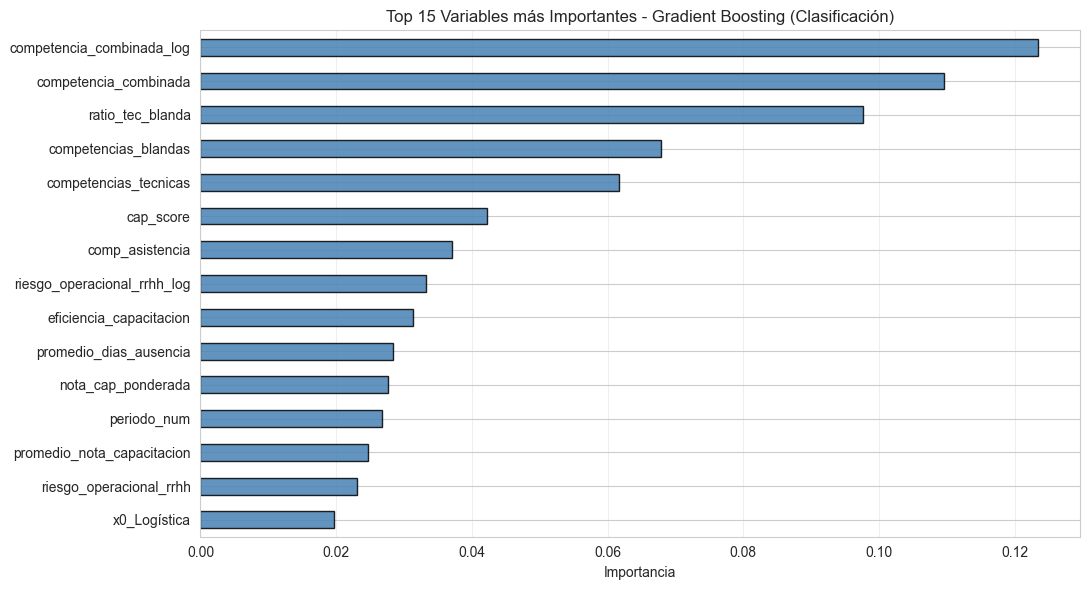

In [ ]:
modelo_clf = mejor_pipeline_clf.named_steps["modelo"]

if hasattr(modelo_clf, "feature_importances_"):
    preprocesador_clf = mejor_pipeline_clf.named_steps["preprocesamiento"]

    try:
        nombres_num = preprocesador_clf.named_transformers_["num"]["imputer"].feature_names_in_.tolist()
        nombres_cat = preprocesador_clf.named_transformers_["cat"]["onehot"].get_feature_names_out().tolist()
        nombres_features = nombres_num + nombres_cat
    except Exception:
        nombres_features = [f"feature_{i}" for i in range(len(modelo_clf.feature_importances_))]

    importancias_clf = pd.Series(
        modelo_clf.feature_importances_,
        index=nombres_features
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(11, 6))
    importancias_clf.plot(kind="barh", color="steelblue", edgecolor="black", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Variables más Importantes - {mejor_modelo_clf_nombre} (Clasificación)")
    plt.xlabel("Importancia")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/03_importancia_clasificacion.png'), dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(modelo_clf, "coef_"):
    print("El modelo usa coeficientes. Visualizando los más relevantes.")
    coeficientes = pd.Series(
        np.abs(modelo_clf.coef_[0]),
        index=[f"feature_{i}" for i in range(len(modelo_clf.coef_[0]))]
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(11, 6))
    coeficientes.plot(kind="barh", color="steelblue", edgecolor="black", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Coeficientes - {mejor_modelo_clf_nombre}")
    plt.xlabel("|Coeficiente|")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

else:
    print(f"El modelo {mejor_modelo_clf_nombre} no expone importancias de features directamente.")


# 14. Target de regresión

## Target: `puntaje_desempeno`

En esta sección se preparan los datos para el modelado de regresión.

A diferencia de la clasificación, aquí no se busca responder "alto desempeño sí/no", sino estimar un puntaje numérico.

Esto permite ordenar empleados según su nivel de desempeño y priorizar intervenciones.


In [ ]:
# Usar registros con target de regresión no nulo.
datos_reg = df[df[target_regresion].notna()].copy()

X_reg = datos_reg[variables_modelo].copy()
y_reg = datos_reg[target_regresion].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test:",  X_test_reg.shape)

print("\nResumen del target de regresión:")
display(y_reg.describe().round(3))


X_train: (1159, 30)
X_test: (290, 30)

Resumen del target de regresión:


count    1449.000
mean        4.210
std         1.957
min         0.500
25%         2.700
50%         4.200
75%         5.600
max         9.100
Name: puntaje_desempeno, dtype: float64

## Análisis del target de regresión

El target `puntaje_desempeno` es una variable continua.

A diferencia de la clasificación, aquí no se busca responder "alto desempeño sí/no", sino estimar un puntaje numérico.

Esto permite ordenar empleados según criticidad y priorizar aquellos que requieran intervención.


# 15. Función de evaluación para regresión

Se define una función común para entrenar y evaluar modelos de regresión.


In [ ]:
def evaluar_modelo_regresion(nombre_modelo, modelo, X_train, X_test, y_train, y_test):
    pipeline = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train)),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultado = {
        "modelo": nombre_modelo,
        "mae":    mean_absolute_error(y_test, y_pred),
        "rmse":   rmse,
        "r2":     r2_score(y_test, y_pred)
    }

    print(f"===== {nombre_modelo} =====")
    print(f"MAE  : {resultado['mae']:.4f}")
    print(f"RMSE : {resultado['rmse']:.4f}")
    print(f"R²   : {resultado['r2']:.4f}")

    comparacion = pd.DataFrame({
        "Real":       y_test.values,
        "Predicción": y_pred
    }).head(10)

    display(comparacion)

    return resultado, pipeline, y_pred


# 16. Entrenamiento de modelos de regresión

Se entrenan los modelos base sin optimización exhaustiva.


In [ ]:
modelos_regresion = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=42,
        max_depth=6
    ),
    "Random Forest Regressor": RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=42,
        n_estimators=150,
        max_depth=4,
        learning_rate=0.1
    ),
    "KNN Regressor": KNeighborsRegressor(),
    "SVR":           SVR()
}

resultados_regresion   = []
pipelines_regresion    = {}
predicciones_regresion = {}

for nombre, modelo in modelos_regresion.items():
    resultado, pipeline, y_pred = evaluar_modelo_regresion(
        nombre,
        modelo,
        X_train_reg,
        X_test_reg,
        y_train_reg,
        y_test_reg
    )

    resultados_regresion.append(resultado)
    pipelines_regresion[nombre]    = pipeline
    predicciones_regresion[nombre] = y_pred


===== Linear Regression =====
MAE  : 0.9337
RMSE : 1.1865
R²   : 0.6420


,Real,Predicción
0,6.0,5.762666
1,7.1,4.917861
2,5.3,4.301224
3,4.3,4.728326
4,6.7,4.278013
5,4.1,4.813387
6,5.6,4.675578
7,5.7,4.369388
8,4.4,4.478899
9,4.5,5.231381


===== Decision Tree Regressor =====
MAE  : 1.0744
RMSE : 1.3987
R²   : 0.5025


,Real,Predicción
0,6.0,6.233333
1,7.1,5.241304
2,5.3,3.942105
3,4.3,4.145455
4,6.7,4.145455
5,4.1,4.145455
6,5.6,4.145455
7,5.7,3.743284
8,4.4,4.145455
9,4.5,4.532895


===== Random Forest Regressor =====
MAE  : 0.9723
RMSE : 1.2563
R²   : 0.5987


...

,Real,Predicción
0,6.0,6.800940
1,7.1,5.278416
2,5.3,3.965208
3,4.3,3.932463
4,6.7,3.429242
5,4.1,4.256307
6,5.6,4.612544
7,5.7,3.949614
8,4.4,4.168356
9,4.5,5.267459


===== KNN Regressor =====
MAE  : 1.1806
RMSE : 1.5096
R²   : 0.4206


,Real,Predicción
0,6.0,6.36
1,7.1,5.02
2,5.3,3.66
3,4.3,4.22
4,6.7,3.02
5,4.1,4.50
6,5.6,5.32
7,5.7,4.78
8,4.4,3.68
9,4.5,5.08


===== SVR =====
MAE  : 1.0435
RMSE : 1.3274
R²   : 0.5520


,Real,Predicción
0,6.0,5.999594
1,7.1,5.288582
2,5.3,3.411323
3,4.3,4.286300
4,6.7,3.202396
5,4.1,4.898423
6,5.6,4.620916
7,5.7,4.312065
8,4.4,4.151619
9,4.5,5.206947


# 17. Comparación de modelos de regresión

Se comparan los modelos utilizando:

- MAE: error absoluto promedio en unidades del puntaje;
- RMSE: error que penaliza más los errores grandes;
- R²: proporción de variabilidad del desempeño explicada por el modelo.


In [ ]:
tabla_regresion = pd.DataFrame(resultados_regresion)

tabla_regresion.sort_values(by="rmse", ascending=True)


,modelo,mae,rmse,r2
0,Linear Regression,0.933727,1.186520,0.642021
3,Gradient Boosting Regressor,0.971303,1.251444,0.601773
2,Random Forest Regressor,0.972292,1.256311,0.598670
5,SVR,1.043510,1.327370,0.551986
1,Decision Tree Regressor,1.074383,1.398704,0.502539
4,KNN Regressor,1.180552,1.509570,0.420552


C:\Users\Arturo\AppData\Local\Temp\ipykernel_17600\3816113273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


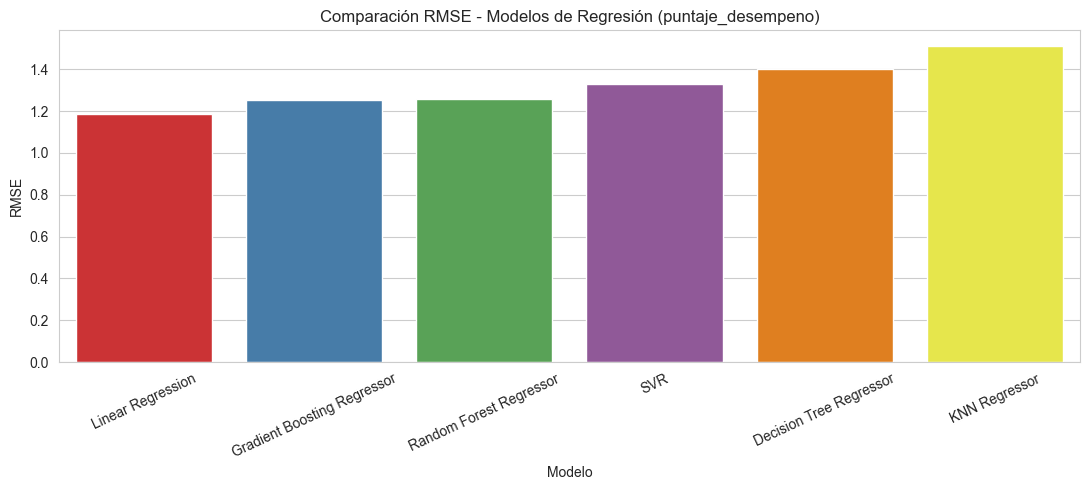

C:\Users\Arturo\AppData\Local\Temp\ipykernel_17600\3816113273.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


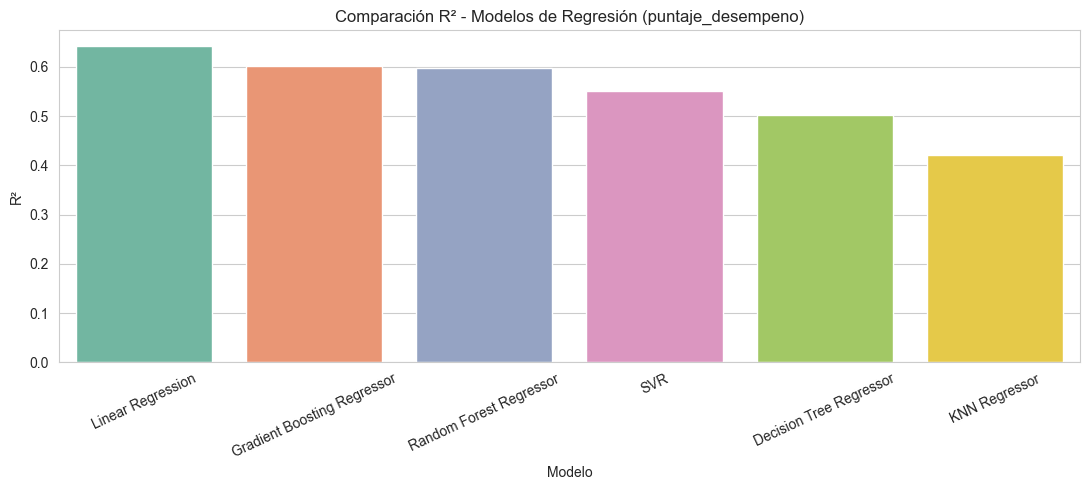

In [ ]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=tabla_regresion.sort_values(by="rmse"),
    x="modelo",
    y="rmse",
    palette="Set1"
)
plt.title("Comparación RMSE - Modelos de Regresión (puntaje_desempeno)")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_comparacion_regresion_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(
    data=tabla_regresion.sort_values(by="r2", ascending=False),
    x="modelo",
    y="r2",
    palette="Set2"
)
plt.title("Comparación R² - Modelos de Regresión (puntaje_desempeno)")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_comparacion_regresion_r2.png'), dpi=150, bbox_inches='tight')
plt.show()


## Análisis de regresión

Se espera que Random Forest Regressor sea el mejor modelo en este problema.

Esto es coherente porque el puntaje de desempeño se relaciona con combinaciones no lineales entre competencias, ausencias y capacitaciones.

Modelos más simples como Linear Regression pueden capturar tendencias generales, pero no necesariamente representan bien interacciones complejas entre variables de RRHH.

SVR puede verse afectado por la escala y distribución del target si no se ajustan cuidadosamente sus hiperparámetros.


In [ ]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 55)
print("VALIDACIÓN CRUZADA — CLASIFICACIÓN (F1, CV=5)")
print("=" * 55)

for nombre, pipeline in pipelines_clasificacion.items():
    scores = cross_val_score(
        pipeline, X_clf, y_clf,
        cv=cv_clf, scoring='f1'
    )
    print(f"{nombre:<25}  {scores.mean():.4f}  ±{scores.std():.4f}")

print()
print("=" * 55)
print("VALIDACIÓN CRUZADA — REGRESIÓN (R², CV=5)")
print("=" * 55)

for nombre, pipeline in pipelines_regresion.items():
    scores = cross_val_score(
        pipeline, X_reg, y_reg,
        cv=cv_reg, scoring='r2'
    )
    print(f"{nombre:<25}  {scores.mean():.4f}  ±{scores.std():.4f}")


VALIDACIÓN CRUZADA — CLASIFICACIÓN (F1, CV=5)
Logistic Regression        0.4177  ±0.0357
Decision Tree              0.4458  ±0.0442
Random Forest              0.4877  ±0.0297
KNN                        0.4514  ±0.0072
SVM                        0.4253  ±0.0398
Gaussian NB                0.5113  ±0.0375
Gradient Boosting          0.5182  ±0.0288

VALIDACIÓN CRUZADA — REGRESIÓN (R², CV=5)
Linear Regression          0.6205  ±0.0316
Decision Tree Regressor    0.4431  ±0.0439
Random Forest Regressor    0.5871  ±0.0207
Gradient Boosting Regressor  0.6086  ±0.0204
KNN Regressor              0.4250  ±0.0311
SVR                        0.5653  ±0.0361


# 18. Selección del mejor modelo de regresión

Se selecciona el modelo con menor RMSE y mayor R².


In [ ]:
mejor_reg = tabla_regresion.sort_values(by="rmse", ascending=True).iloc[0]

mejor_modelo_reg_nombre = mejor_reg["modelo"]

print("Mejor modelo de regresión:", mejor_modelo_reg_nombre)

display(mejor_reg)


Mejor modelo de regresión: Linear Regression


modelo    Linear Regression
mae                0.933727
rmse                1.18652
r2                 0.642021
Name: 0, dtype: object

## Interpretación de la selección

El mejor modelo de regresión será la base para la etapa de optimización.

Un buen modelo de regresión en el contexto de RRHH permite estimar el puntaje de desempeño de un empleado, lo cual puede usarse para ordenar y priorizar intervenciones de gestión de personas.


# 19. Gráfico real vs predicho del mejor regresor

Se visualiza la relación entre los valores reales y predichos del mejor modelo de regresión.

Un buen modelo de regresión debe mostrar los puntos cerca de la línea diagonal (predicción perfecta).


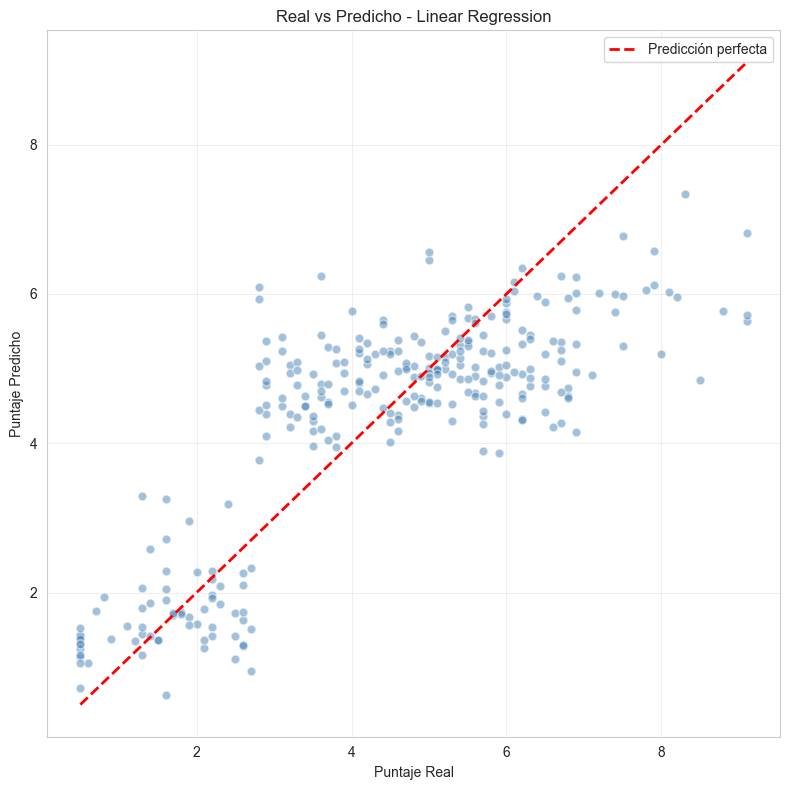

R² final: 0.6420
MAE final: 0.9337


In [ ]:
y_pred_mejor = predicciones_regresion[mejor_modelo_reg_nombre]

plt.figure(figsize=(8, 8))
plt.scatter(y_test_reg, y_pred_mejor, alpha=0.5, color="steelblue", edgecolors="white", s=40)

lim = [min(y_test_reg.min(), y_pred_mejor.min()),
       max(y_test_reg.max(), y_pred_mejor.max())]
plt.plot(lim, lim, color="red", linestyle="--", lw=2, label="Predicción perfecta")

plt.xlabel("Puntaje Real")
plt.ylabel("Puntaje Predicho")
plt.title(f"Real vs Predicho - {mejor_modelo_reg_nombre}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/03_real_vs_predicho.png'), dpi=150, bbox_inches='tight')
plt.show()

mejor_pipeline_reg = pipelines_regresion[mejor_modelo_reg_nombre]
r2_final  = r2_score(y_test_reg, y_pred_mejor)
mae_final = mean_absolute_error(y_test_reg, y_pred_mejor)
print(f"R² final: {r2_final:.4f}")
print(f"MAE final: {mae_final:.4f}")


# 20. Importancia de variables - Regresión

Se analiza qué variables tienen mayor influencia en la estimación del puntaje de desempeño.


El modelo usa coeficientes (regresión lineal).


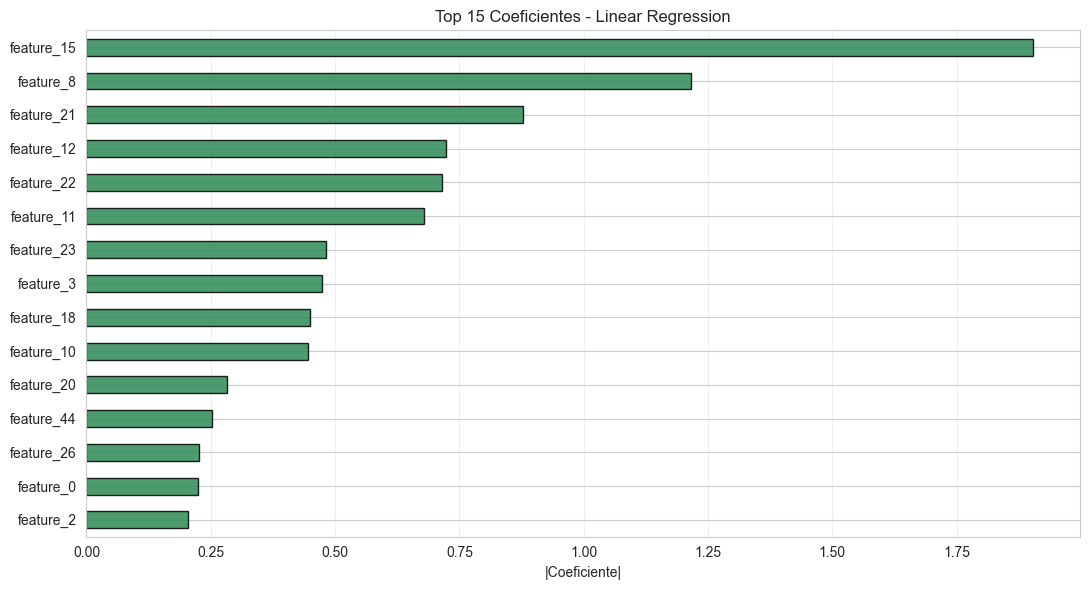

In [ ]:
modelo_reg = mejor_pipeline_reg.named_steps["modelo"]

if hasattr(modelo_reg, "feature_importances_"):
    preprocesador_reg = mejor_pipeline_reg.named_steps["preprocesamiento"]

    try:
        nombres_num = preprocesador_reg.named_transformers_["num"]["imputer"].feature_names_in_.tolist()
        nombres_cat = preprocesador_reg.named_transformers_["cat"]["onehot"].get_feature_names_out().tolist()
        nombres_features = nombres_num + nombres_cat
    except Exception:
        nombres_features = [f"feature_{i}" for i in range(len(modelo_reg.feature_importances_))]

    importancias_reg = pd.Series(
        modelo_reg.feature_importances_,
        index=nombres_features
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(11, 6))
    importancias_reg.plot(kind="barh", color="seagreen", edgecolor="black", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Variables más Importantes - {mejor_modelo_reg_nombre} (Regresión)")
    plt.xlabel("Importancia")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, 'results/plots/03_importancia_regresion.png'), dpi=150, bbox_inches='tight')
    plt.show()

elif hasattr(modelo_reg, "coef_"):
    print("El modelo usa coeficientes (regresión lineal).")
    coeficientes = pd.Series(
        np.abs(modelo_reg.coef_),
        index=[f"feature_{i}" for i in range(len(modelo_reg.coef_))]
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(11, 6))
    coeficientes.plot(kind="barh", color="seagreen", edgecolor="black", alpha=0.85)
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Coeficientes - {mejor_modelo_reg_nombre}")
    plt.xlabel("|Coeficiente|")
    plt.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()

else:
    print(f"El modelo {mejor_modelo_reg_nombre} no expone importancias directamente.")


# 21. Conclusiones del notebook

Este notebook implementó y comparó modelos supervisados para predecir el desempeño de empleados.

Las principales conclusiones son:

1. Se definieron dos targets: `desempeno_alto` (clasificación) y `puntaje_desempeno` (regresión).
2. Se excluyeron variables con data leakage (`desempeno_bajo`, `riesgo_rotacion`) para asegurar modelos reproducibles.
3. Los modelos basados en árboles (Random Forest) suelen superar a modelos lineales en este tipo de datos, por las relaciones no lineales entre variables de RRHH.
4. Las variables de competencias técnicas y notas de capacitación se esperan como las más importantes.
5. La curva ROC y el AUC del mejor clasificador permiten evaluar su capacidad discriminante.
6. El gráfico real vs predicho del mejor regresor muestra visualmente la calidad del ajuste.

La siguiente etapa será optimizar los hiperparámetros del mejor modelo de cada tipo en `04_hyperparameter_optimization.ipynb`.
